### **[Static ETF-ETF Hedge Ratios: PyDLM Dynamically Hedges `SPY–QQQ`](https://medium.com/@alexzap922/11938d2ada30)**

> *From Fixed Beta to Dynamic Hedge Ratio with Bayesian Dynamic Linear Model (DLM)*

In [1]:
!pip install -qq pydlm
!python -c "import pydlm; print('PyDLM import: OK')"
!python -c "from importlib.metadata import version; print('PyDLM:', version('pydlm'))"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 2.3 MB/s eta 0:00:00
PyDLM import: OK
PyDLM: 0.1.1.13


In [2]:
!wget -O data.csv 'https://raw.githubusercontent.com/wwrechard/pydlm/refs/heads/master/examples/unemployment_insurance/data.csv'

--2026-08-31 16:46:43--  https://raw.githubusercontent.com/wwrechard/pydlm/refs/heads/master/examples/unemployment_insurance/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32860 (32K) [text/plain]
Saving to: ‘data.csv’

data.csv            100%[===================>]  32.09K  --.-KB/s    in 0.003s  

2026-08-31 16:46:43 (11.1 MB/s) - ‘data.csv’ saved [32860/32860]



In [3]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

this_dir = os.getcwd()
DATA_PATH = os.path.join(this_dir, "data.csv")
data_file = open(DATA_PATH, "r")

variables = data_file.readline().strip().split(",")
data_map = {}
for var in variables:
  data_map[var] = []

for line in data_file:
  for i, data_piece in enumerate(line.strip().split(",")):
    data_map[variables[i]].append(float(data_piece))

# Extract and store the data.
time_series = data_map[variables[0]]
features = [
  [data_map[variables[j]][i] for j in range(1, len(variables))]
  for i in range(len(time_series))
]

#### **Building a simple `PyDLM` model**

In [4]:
# Build a simple model
from pydlm import dlm, trend, seasonality

# A linear trend
linear_trend = trend(degree=1, discount=0.95, name="linear_trend", w=10)
# A seasonality
seasonal52 = seasonality(period=52, discount=0.99, name="seasonal52", w=10)

simple_dlm = dlm(time_series) + linear_trend + seasonal52
simple_dlm.fit()

INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...
INFO:pydlm:Forward filtering completed.
INFO:pydlm:Starting backward smoothing...
INFO:pydlm:Backward smoothing completed.


#### **Building a dynamic regression model**

In [5]:
# Build a dynamic regression model
from pydlm import dynamic

regressor10 = dynamic(features=features, discount=1.0, name="regressor10", w=10)
drm = dlm(time_series) + linear_trend + seasonal52 + regressor10
drm.fit()

INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...
INFO:pydlm:Forward filtering completed.
INFO:pydlm:Starting backward smoothing...
INFO:pydlm:Backward smoothing completed.


#### **Connecting directly to the Kalman filter**

In [6]:
import numpy as np

filtered_mean = np.asarray(
  simple_dlm.getMean(
    filterType="forwardFilter"
  ),
  dtype=float
).reshape(-1)

filtered_var = np.asarray(
  simple_dlm.getVar(
    filterType="forwardFilter"
  ),
  dtype=float
).reshape(-1)

actual = np.asarray(time_series, dtype=float).reshape(-1)

print("Actual shape:        ", actual.shape)
print("Filtered mean shape: ", filtered_mean.shape)
print("Filtered var shape:  ", filtered_var.shape)

Actual shape:         (456,)
Filtered mean shape:  (456,)
Filtered var shape:   (456,)


#### **Comparing aligned observed vs DLM-filtered time series**

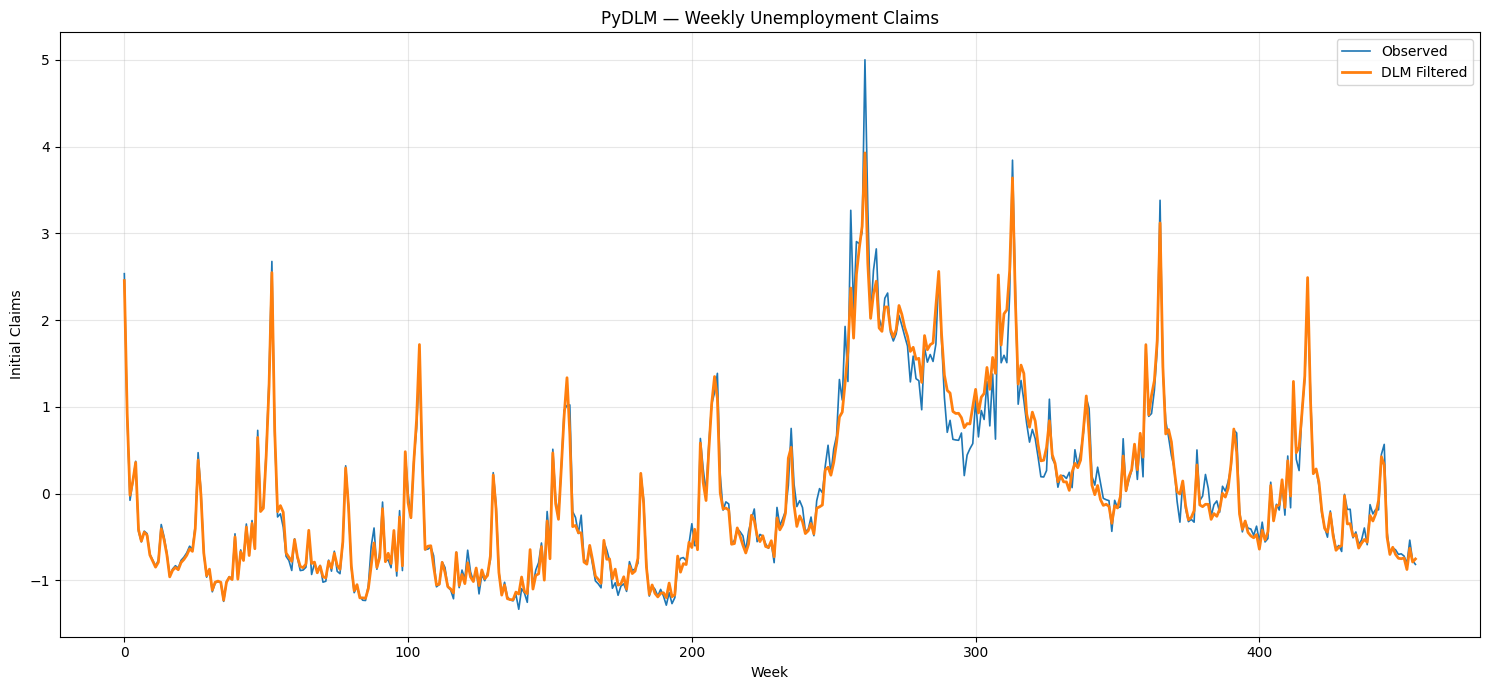

In [7]:
plt.figure(figsize=(15, 7))

plt.plot(actual, label="Observed", linewidth=1.2)
plt.plot(filtered_mean, label="DLM Filtered", linewidth=2)
plt.title("PyDLM — Weekly Unemployment Claims")

plt.xlabel("Week")
plt.ylabel("Initial Claims")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

#### **Adding 95% Confidence Intervals (CI)**

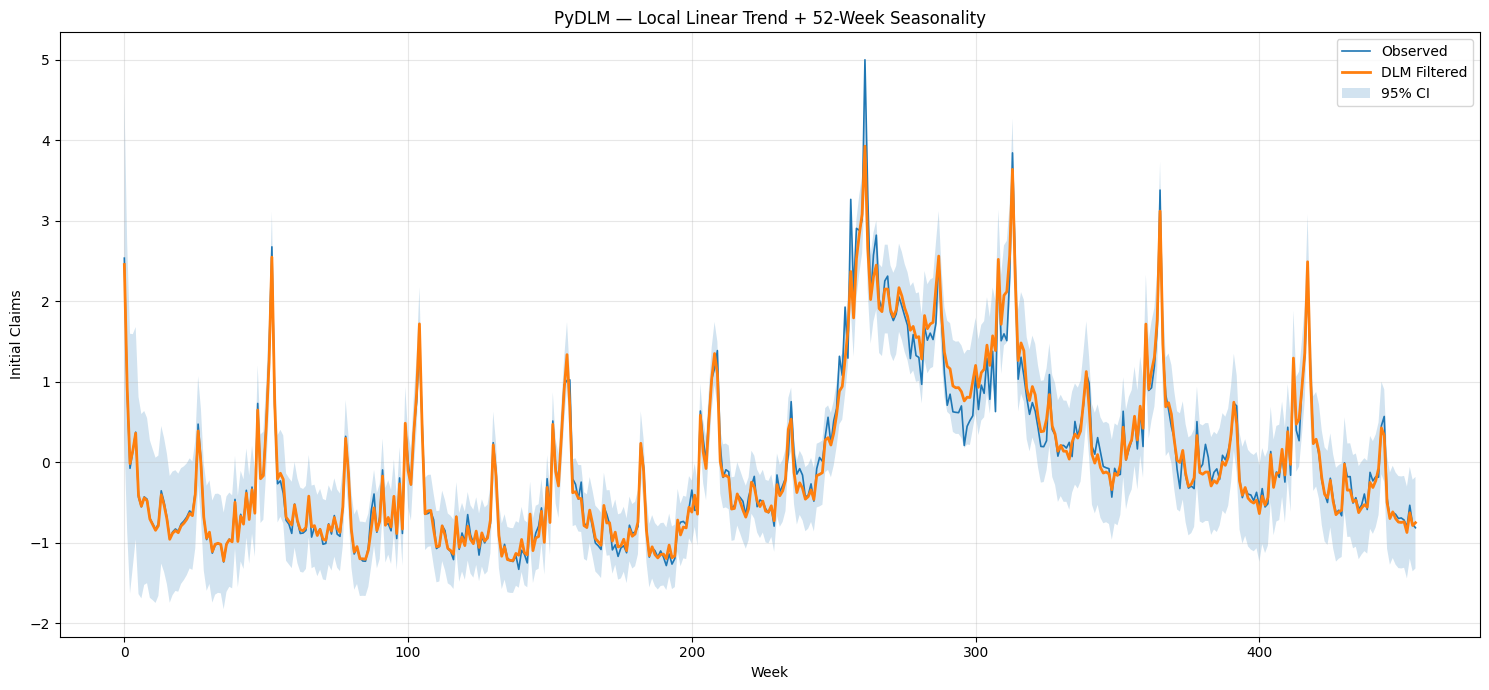

In [8]:
filtered_std = np.sqrt(
  np.maximum(filtered_var, 0)
)

upper = (
  filtered_mean + 1.96 * filtered_std
)

lower = (
  filtered_mean - 1.96 * filtered_std
)

plt.figure(figsize=(15, 7))

plt.plot(actual, label="Observed", linewidth=1.2)
plt.plot(filtered_mean, label="DLM Filtered", linewidth=2)

plt.fill_between(
  np.arange(len(filtered_mean)),
  lower,
  upper,
  alpha=0.2,
  label="95% CI"
)

plt.title("PyDLM — Local Linear Trend + 52-Week Seasonality")

plt.xlabel("Week")
plt.ylabel("Initial Claims")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

#### **Visualizing the Local Linear Trend**

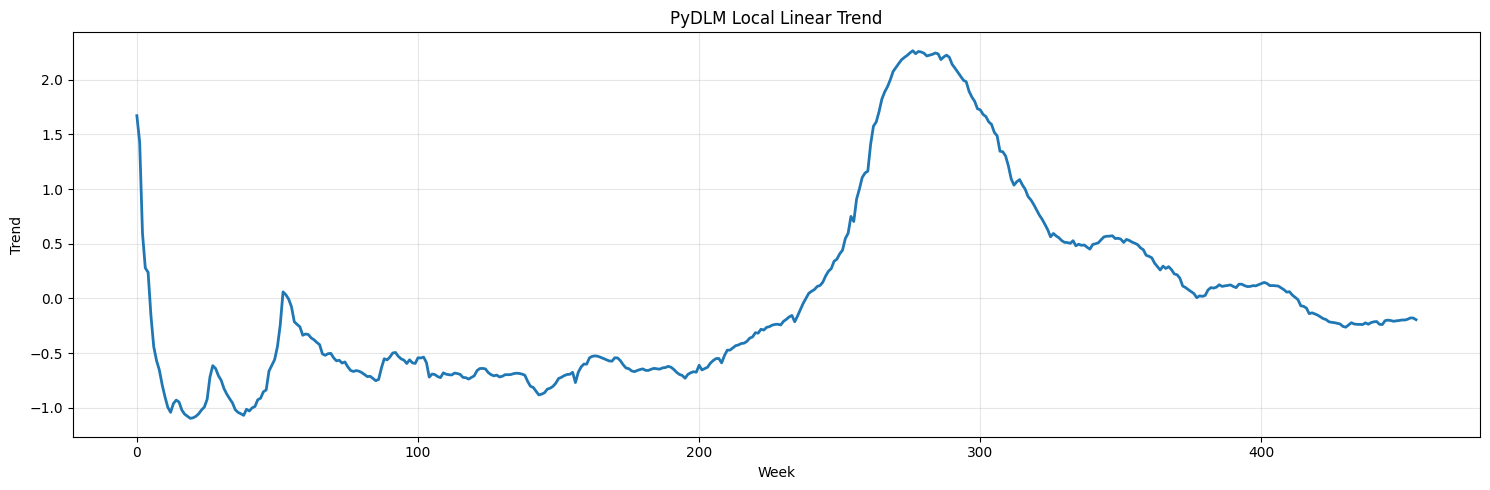

In [9]:
trend_mean = np.asarray(
  simple_dlm.getMean(
    filterType="forwardFilter",
    name="linear_trend"
  ),
  dtype=float
).reshape(-1)

plt.figure(figsize=(15, 5))

plt.plot(trend_mean, linewidth=2)
plt.title("PyDLM Local Linear Trend")

plt.xlabel("Week")
plt.ylabel("Trend")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **Examining the 52-Week Seasonal Component**

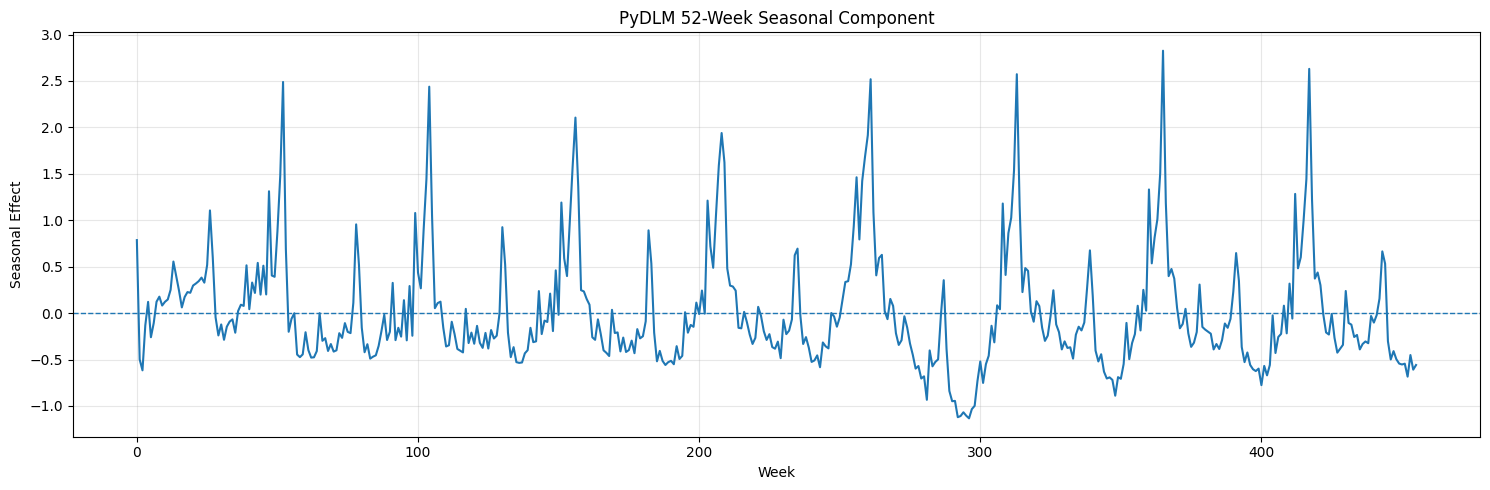

In [10]:
seasonal_mean = np.asarray(
  simple_dlm.getMean(
    filterType="forwardFilter",
    name="seasonal52"
  ),
  dtype=float
).reshape(-1)

plt.figure(figsize=(15, 5))

plt.plot(seasonal_mean, linewidth=1.5)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("PyDLM 52-Week Seasonal Component")

plt.xlabel("Week")
plt.ylabel("Seasonal Effect")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **Building a Complete PyDLM Dynamic Regression Model by Revisiting Step 3**

INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...
INFO:pydlm:Forward filtering completed.
INFO:pydlm:Starting backward smoothing...


Fitting PyDLM dynamic regression model...


INFO:pydlm:Backward smoothing completed.


Model fitted successfully.

PYDLM MODEL PERFORMANCE
One-step-ahead MSE: 0.099531

Shapes:
Actual:          (456,)
Filtered mean:   (456,)
Filtered var:    (456,)


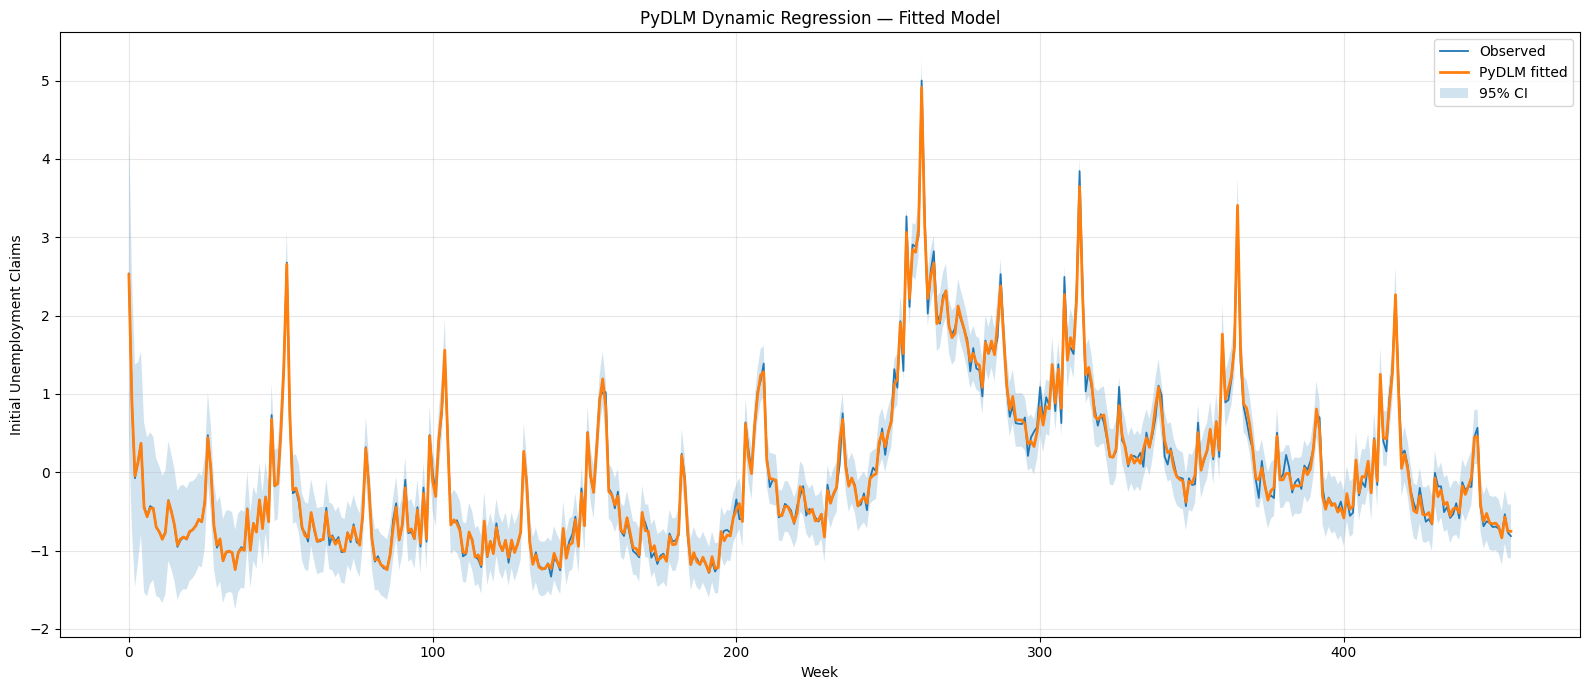

In [11]:
# Build a dynamic regression model
# ============================================================
# PyDLM Dynamic Regression Model
# Manual Plotting — avoids drm.plot()
# ============================================================
from pydlm import dlm, trend, seasonality, dynamic

# ============================================================
# 1. BUILD DYNAMIC REGRESSION COMPONENT
# ============================================================
regressor10 = dynamic(
  features=features,
  discount=1.0,
  name="regressor10",
  w=10
)


# ============================================================
# 2. BUILD COMPLETE DLM
# ============================================================
drm = (
  dlm(time_series) + linear_trend + seasonal52 + regressor10
)


# ============================================================
# 3. FIT MODEL
# ============================================================
print("Fitting PyDLM dynamic regression model...")
drm.fit()
print("Model fitted successfully.")


# ============================================================
# 4. MSE
# ============================================================
mse = drm.getMSE()

print("\n" + "=" * 70)
print("PYDLM MODEL PERFORMANCE")
print("=" * 70)
print(f"One-step-ahead MSE: {mse:.6f}")


# ============================================================
# 5. EXTRACT FILTERED OBSERVATIONS
# ============================================================

filtered_mean = np.asarray(
  drm.getMean(
    filterType="forwardFilter"
  ),
  dtype=float
).reshape(-1)


filtered_var = np.asarray(
  drm.getVar(
    filterType="forwardFilter"
  ),
  dtype=float
).reshape(-1)


actual = np.asarray(time_series, dtype=float).reshape(-1)


# ============================================================
# 6. CHECK SHAPES
# ============================================================
print("\nShapes:")
print("Actual:         ", actual.shape)
print("Filtered mean:  ", filtered_mean.shape)
print("Filtered var:   ", filtered_var.shape)


# ============================================================
# 7. HANDLE POSSIBLE LENGTH DIFFERENCES
# ============================================================
n = min(
  len(actual),
  len(filtered_mean),
  len(filtered_var)
)

actual_plot = actual[:n]
filtered_plot = filtered_mean[:n]
filtered_var_plot = filtered_var[:n]


# ============================================================
# 8. 95% CONFIDENCE INTERVAL
# ============================================================

filtered_std = np.sqrt(
  np.maximum(filtered_var_plot, 0)
)


upper = (
  filtered_plot + 1.96 * filtered_std
)


lower = (
  filtered_plot - 1.96 * filtered_std
)


# ============================================================
# 9. MAIN FITTED MODEL PLOT
# ============================================================
x = np.arange(n)

plt.figure(figsize=(16, 7))

plt.plot(
  x,
  actual_plot,
  label="Observed",
  linewidth=1.3
)

plt.plot(
  x,
  filtered_plot,
  label="PyDLM fitted",
  linewidth=2
)

plt.fill_between(
  x,
  lower,
  upper,
  alpha=0.20,
  label="95% CI"
)

plt.title("PyDLM Dynamic Regression — Fitted Model")
plt.xlabel("Week")
plt.ylabel("Initial Unemployment Claims")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### **Plotting the Local Linear Trend of Dynamic Regression**

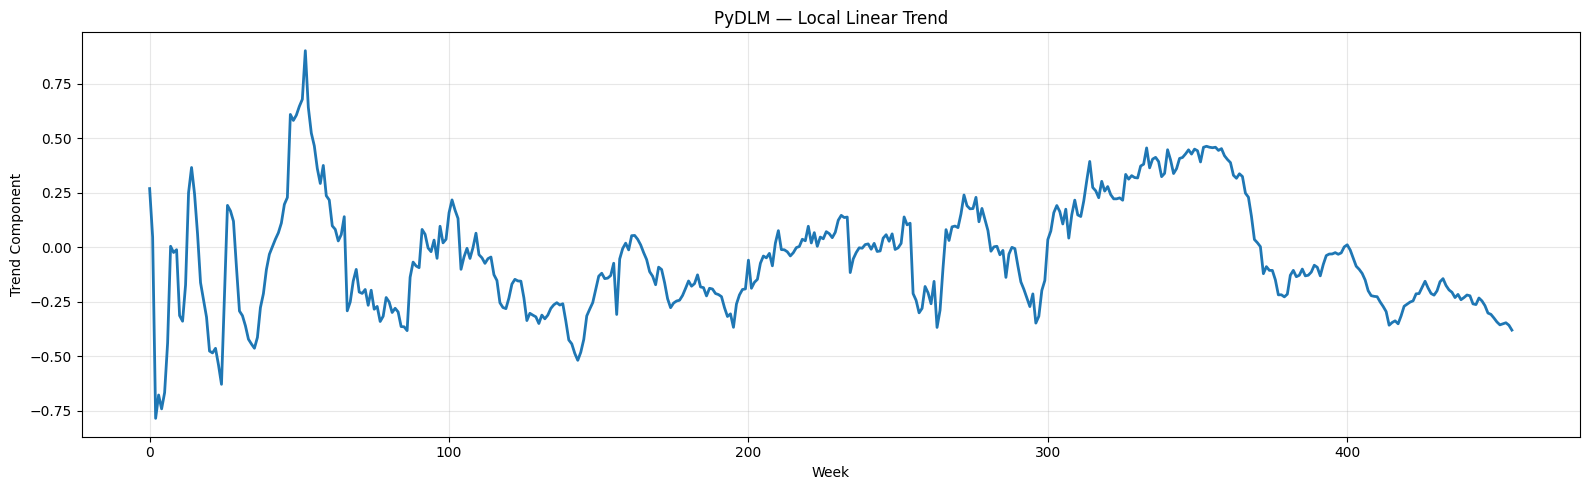

In [12]:
# ============================================================
# LOCAL LINEAR TREND
# ============================================================

trend_mean = np.asarray(
  drm.getMean(
    filterType="forwardFilter",
    name="linear_trend"
  ),
  dtype=float
).reshape(-1)

n_trend = min(len(actual), len(trend_mean))

plt.figure(figsize=(16, 5))

plt.plot(
  x[:n_trend],
  trend_mean[:n_trend],
  linewidth=2
)

plt.title("PyDLM — Local Linear Trend")
plt.xlabel("Week")
plt.ylabel("Trend Component")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Plotting the 52-Week Seasonal Component of Dynamic Regression**

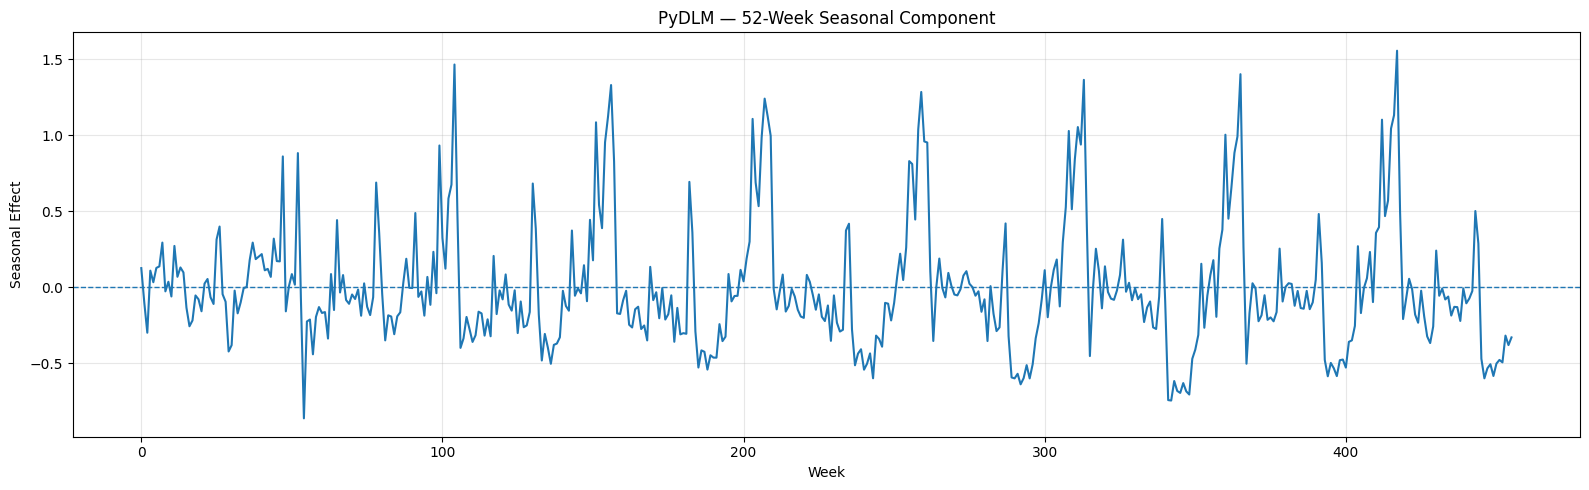

In [13]:
# ============================================================
# 52-WEEK SEASONAL COMPONENT
# ============================================================
seasonal_mean = np.asarray(
  drm.getMean(
    filterType="forwardFilter",
    name="seasonal52"
  ),
  dtype=float
).reshape(-1)
n_seasonal = min(len(actual), len(seasonal_mean))

plt.figure(figsize=(16, 5))

plt.plot(
  x[:n_seasonal],
  seasonal_mean[:n_seasonal],
  linewidth=1.5
)

plt.axhline(
  0,
  linestyle="--",
  linewidth=1
)

plt.title("PyDLM — 52-Week Seasonal Component")
plt.xlabel("Week")
plt.ylabel("Seasonal Effect")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Extracting and displaying the dynamic regression component from our PyDLM model**

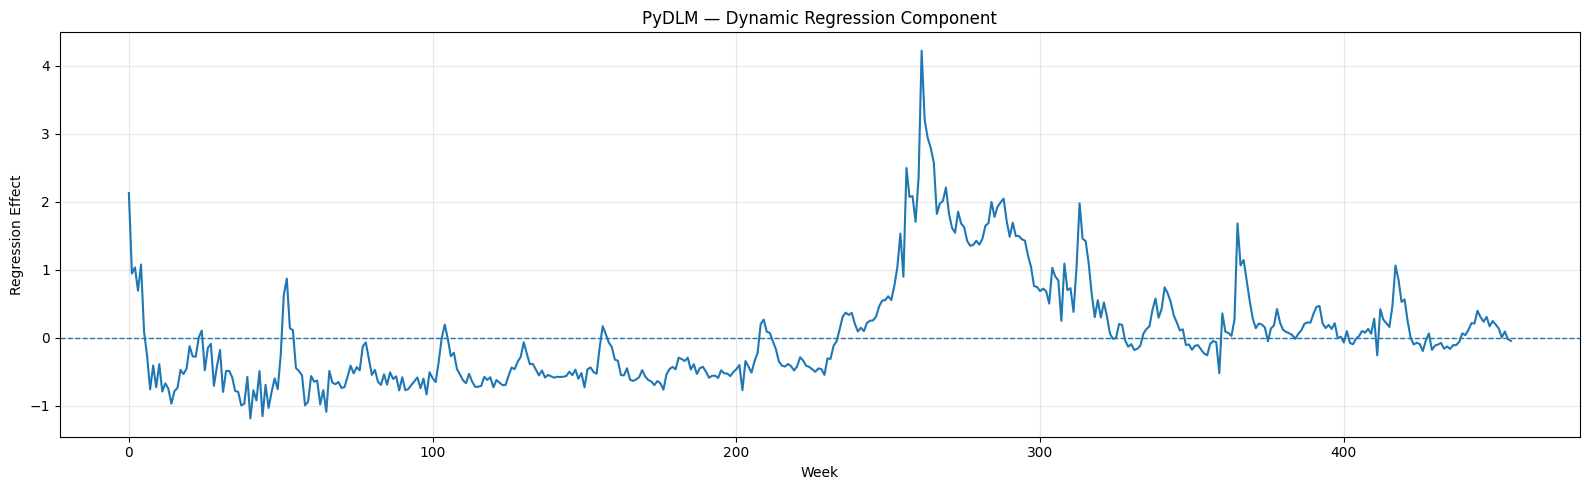

In [14]:
# ============================================================
# DYNAMIC REGRESSION COMPONENT
# ============================================================
regression_mean = np.asarray(
  drm.getMean(
    filterType="forwardFilter",
    name="regressor10"
  ),
  dtype=float
).reshape(-1)

n_regression = min(len(actual), len(regression_mean))

plt.figure(figsize=(16, 5))

plt.plot(
  x[:n_regression],
  regression_mean[:n_regression],
  linewidth=1.5
)

plt.axhline(
  0,
  linestyle="--",
  linewidth=1
)

plt.title("PyDLM — Dynamic Regression Component")
plt.xlabel("Week")
plt.ylabel("Regression Effect")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Aligning the three PyDLM components**

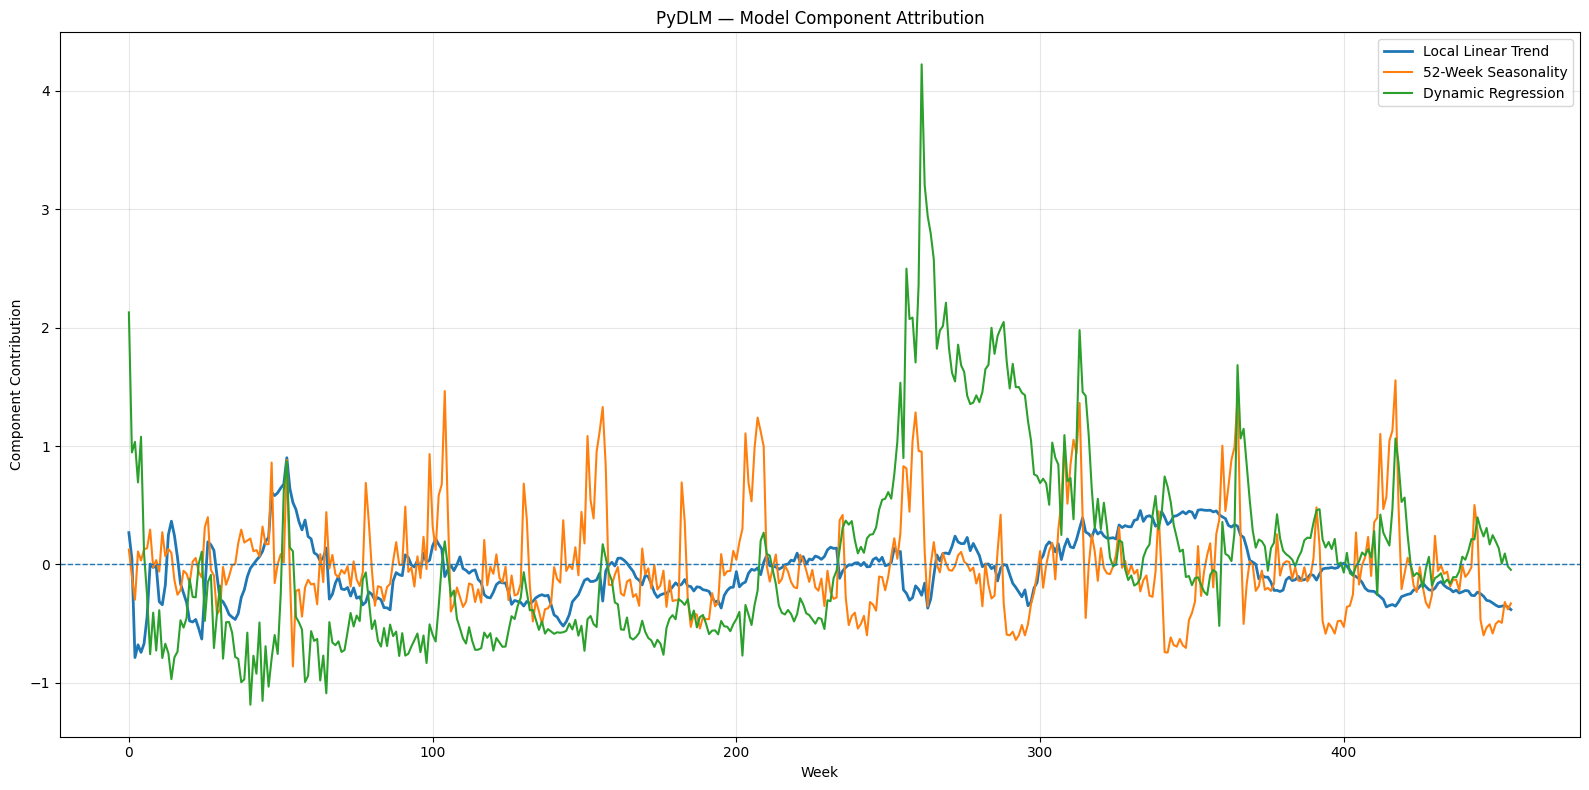

In [15]:
# COMPONENT ATTRIBUTION
# ============================================================

n_components = min(
  len(actual),
  len(trend_mean),
  len(seasonal_mean),
  len(regression_mean)
)

trend_plot = trend_mean[:n_components]
seasonal_plot = seasonal_mean[:n_components]
regression_plot = regression_mean[:n_components]
x_comp = np.arange(n_components)

plt.figure(figsize=(16, 8))

plt.plot(
  x_comp,
  trend_plot,
  label="Local Linear Trend",
  linewidth=2
)

plt.plot(
  x_comp,
  seasonal_plot,
  label="52-Week Seasonality",
  linewidth=1.5
)

plt.plot(
  x_comp,
  regression_plot,
  label="Dynamic Regression",
  linewidth=1.5
)

plt.axhline(
  0,
  linestyle="--",
  linewidth=1
)

plt.title("PyDLM — Model Component Attribution")
plt.xlabel("Week")
plt.ylabel("Component Contribution")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### **Comparing the Mean Squared Error (MSE)**

In [16]:
# ============================================================
# SIMPLE DLM VS DYNAMIC REGRESSION
# ============================================================
simple_mse = simple_dlm.getMSE()
dynamic_mse = drm.getMSE()

comparison = pd.DataFrame(
  {
    "Model": [
      "Trend + Seasonality",
      "Trend + Seasonality + Dynamic Regression"
    ],
    "MSE": [
      simple_mse,
      dynamic_mse
    ]
  }
)

display(comparison.round(6))

mse_improvement = (
  1 - dynamic_mse / simple_mse
)
print(f"\nMSE improvement: {mse_improvement:.2%}")

,Model,MSE
0,Trend + Seasonality,0.173024
1,Trend + Seasonality + Dynamic Regression,0.099531



MSE improvement: 42.48%


#### **Building and fitting a complete Bayesian DLM**

In [17]:
# ============================================================
# PyDLM Dynamic Regression + Renewal Strategy
# ============================================================
from pydlm import (
  dlm,
  trend,
  seasonality,
  dynamic
)


# ============================================================
# 1. COMPONENTS
# ============================================================

linear_trend = trend(
  degree=1,
  discount=0.95,
  name="linear_trend",
  w=10
)

seasonal52 = seasonality(
  period=52,
  discount=0.99,
  name="seasonal52",
  w=10
)

regressor10 = dynamic(
  features=features,
  discount=0.90,
  name="regressor10",
  w=10
)


# ============================================================
# 2. BUILD MODEL
# ============================================================
drm = (
  dlm(time_series) + linear_trend + seasonal52 + regressor10
)


# ============================================================
# 3. ENABLE RENEWAL / STABLE MODE
# ============================================================
drm.stableMode(True)


# ============================================================
# 4. FIT
# ============================================================
print("Fitting DLM with renewal strategy...")
drm.fit()
print("Finished.")


# ============================================================
# 5. MSE
# ============================================================
mse = drm.getMSE()
print(f"\nOne-step-ahead MSE: {mse:.6f}")

INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...


Fitting DLM with renewal strategy...


INFO:pydlm:Forward filtering completed.
INFO:pydlm:Starting backward smoothing...
INFO:pydlm:Backward smoothing completed.


Finished.

One-step-ahead MSE: 0.174784


#### **Figuring out how many time steps it takes for an old observation’s**

In [18]:
# ============================================================
# RENEWAL LENGTH CALCULATOR
# ============================================================

def renewal_length(discount, information_loss=0.001):
    """
    Calculate approximate renewal length.

    discount:
      PyDLM discount factor

    information_loss:
      Maximum remaining information.
      0.001 = 0.1%
    """
    if discount >= 1.0:
      return None

    return int(
      np.ceil(
        np.log(information_loss) / np.log(discount)
      )
    )

for d in [0.80, 0.85, 0.90, 0.95, 0.99]:
  n = renewal_length(d)
  print(f"discount={d:.2f} " f"-> renewal length ≈ {n}")

discount=0.80 -> renewal length ≈ 31
discount=0.85 -> renewal length ≈ 43
discount=0.90 -> renewal length ≈ 66
discount=0.95 -> renewal length ≈ 135
discount=0.99 -> renewal length ≈ 688


#### **Calculating the approximate information renewal length**

In [19]:
components = {
  "linear_trend": 0.95,
  "seasonal52": 0.99,
  "regressor10": 0.90
}

for name, discount in components.items():
  n = renewal_length(discount)
  print(
    f"{name:15s} "
    f"discount={discount:.2f} "
    f"renewal≈{n}"
  )

linear_trend    discount=0.95 renewal≈135
seasonal52      discount=0.99 renewal≈688
regressor10     discount=0.90 renewal≈66


#### **Extracting PyDLM’s filtered estimates and uncertainty**

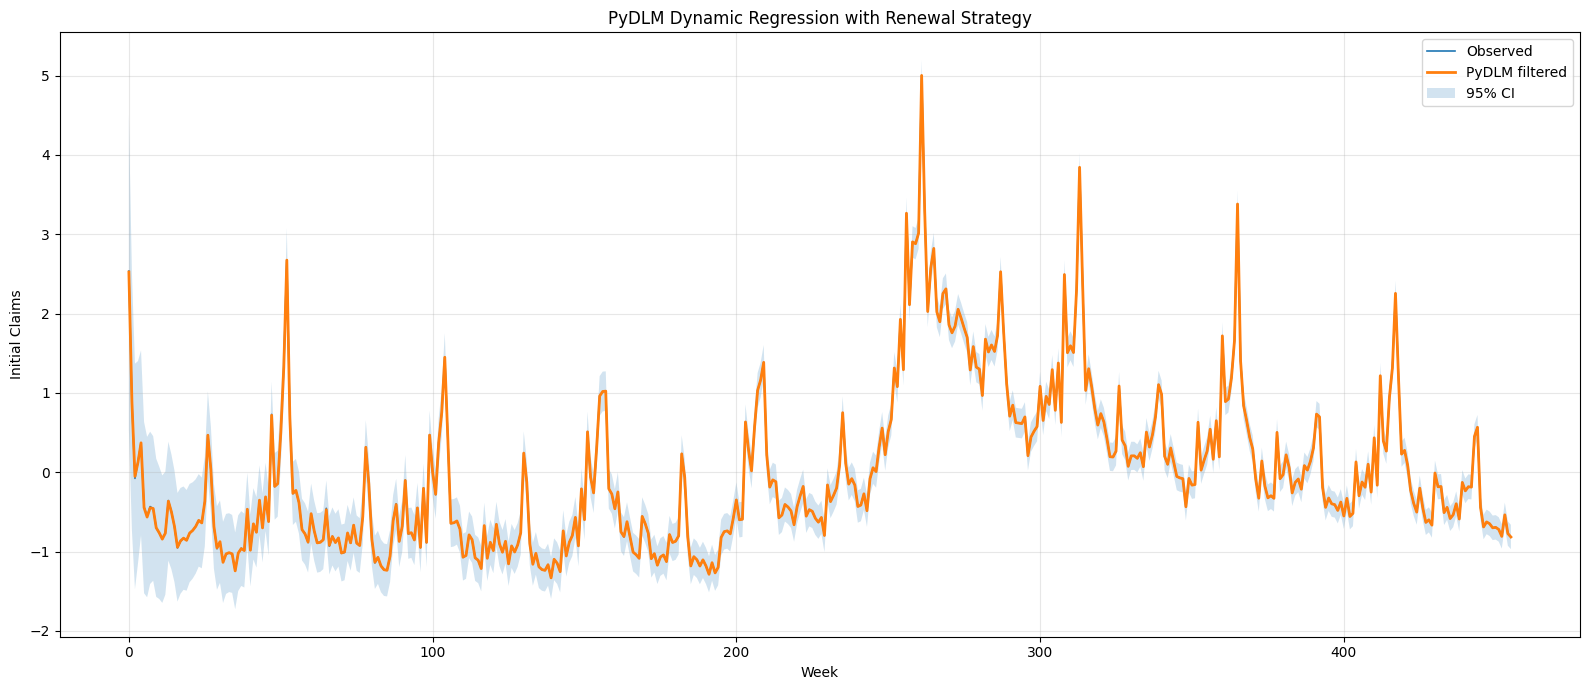

In [20]:
# ============================================================
# EXTRACT FILTERED SERIES
# ============================================================
filtered_mean = np.asarray(
  drm.getMean(
    filterType="forwardFilter"
  ),
  dtype=float
).reshape(-1)

filtered_var = np.asarray(
  drm.getVar(
    filterType="forwardFilter"
  ),
  dtype=float
).reshape(-1)

actual = np.asarray(time_series, dtype=float).reshape(-1)

n = min(len(actual), len(filtered_mean))

actual = actual[:n]
filtered_mean = filtered_mean[:n]
filtered_var = filtered_var[:n]


# ============================================================
# CONFIDENCE INTERVAL
# ============================================================
std = np.sqrt(np.maximum(filtered_var, 0))
upper = filtered_mean + 1.96 * std
lower = filtered_mean - 1.96 * std


# ============================================================
# PLOT
# ============================================================

x = np.arange(n)
plt.figure(figsize=(16, 7))
plt.plot(
  x,
  actual,
  label="Observed",
  linewidth=1.2
)

plt.plot(
  x,
  filtered_mean,
  label="PyDLM filtered",
  linewidth=2
)

plt.fill_between(
  x,
  lower,
  upper,
  alpha=0.20,
  label="95% CI"
)

plt.title("PyDLM Dynamic Regression with Renewal Strategy")
plt.xlabel("Week")
plt.ylabel("Initial Claims")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### **Visualizing PyDLM Component Attribution — Renewal Strategy**

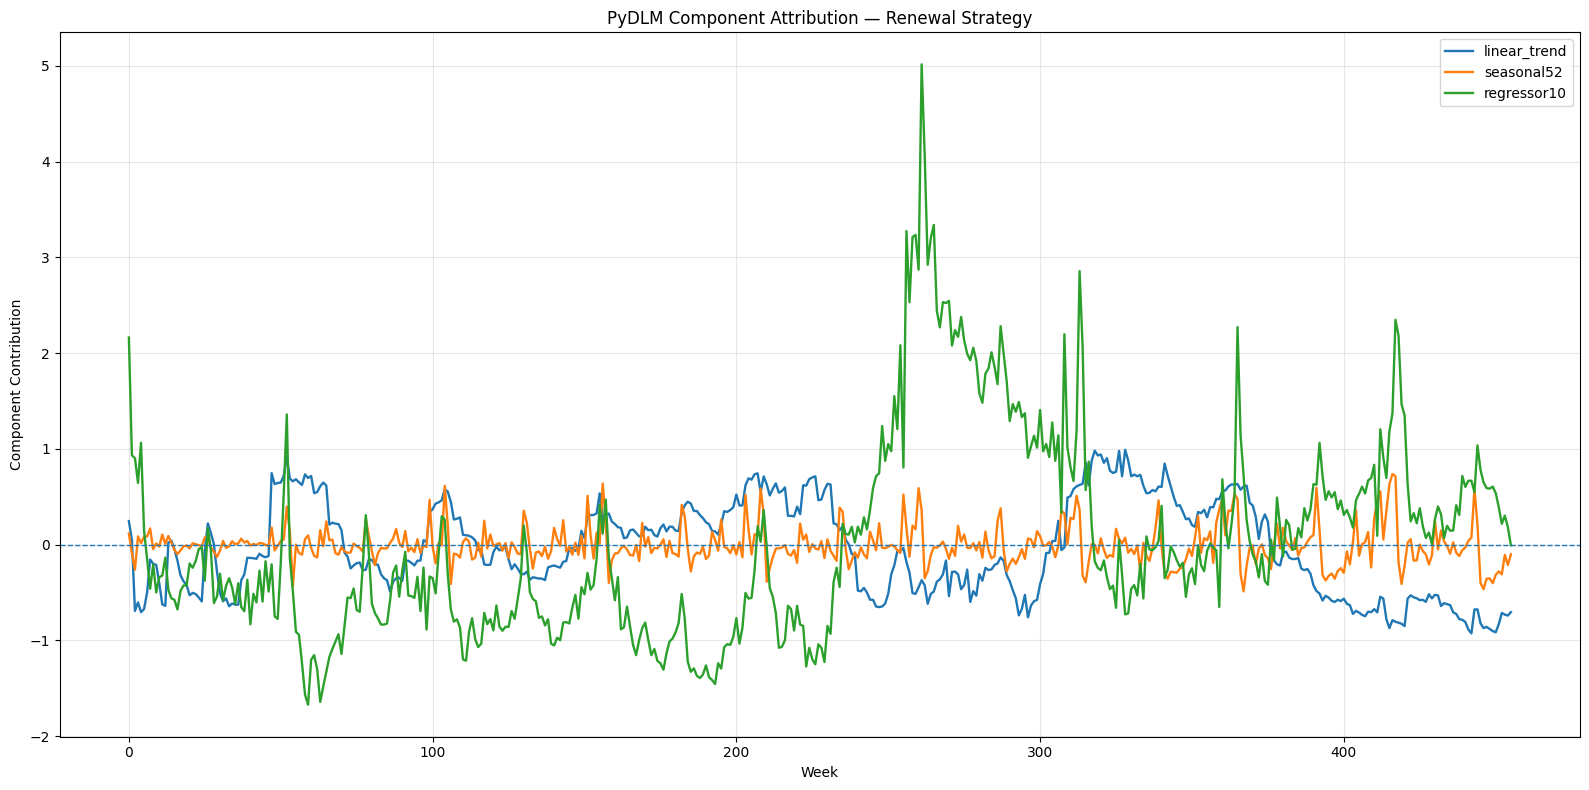

In [21]:
# ============================================================
# COMPONENT EXTRACTION
# ============================================================

components = {}
for name in ["linear_trend", "seasonal52", "regressor10"]:
  values = np.asarray(
    drm.getMean(
      filterType="forwardFilter",
      name=name
    ),
    dtype=float
  ).reshape(-1)

  components[name] = values

# ============================================================
# COMPONENT ATTRIBUTION
# ============================================================

plt.figure(figsize=(16, 8))

for name, values in components.items():
  n_component = min(
    n,
    len(values)
  )

  plt.plot(
    x[:n_component],
    values[:n_component],
    label=name,
    linewidth=1.7
  )

plt.axhline(
  0,
  linestyle="--",
  linewidth=1
)

plt.title("PyDLM Component Attribution — Renewal Strategy")
plt.xlabel("Week")
plt.ylabel("Component Contribution")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()